# nav

In [3]:
import pandas as pd
import numpy as np

nav = pd.read_csv('../data/processed/clean_nav_history.csv', parse_dates=['date'])
nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [4]:
nav['daily_returns'] = nav.groupby('amfi_code')['nav'].pct_change()

In [5]:
nav['annual_return'] = (nav.groupby('amfi_code')['daily_returns'].transform(
              lambda x: (1 + x.dropna()).prod() ** (252 / len(x.dropna())) - 1))

nav.to_csv('../data/processed/returns_computed.csv')

# scheme & nav

In [6]:
scheme = pd.read_csv('../data/processed/clean_scheme_performance.csv')
nav = pd.read_csv('../data/processed/clean_nav_history.csv', parse_dates=['date'])

nav = nav.sort_values(['amfi_code', 'date'])

In [7]:
def calculate_cagr(group, years):
    end_date = group['date'].max()
    start_date = end_date - pd.DateOffset(years=years)

    start_rows = group[group['date'] >= start_date]

    if start_rows.empty:
        return np.nan

    nav_start = start_rows.iloc[0]['nav']
    nav_end = group.iloc[-1]['nav']

    return ((nav_end / nav_start) ** (1 / years) - 1) * 100

cagr_df = (
    nav.groupby('amfi_code').apply(lambda g: pd.Series({
           'return_1yr_pct': calculate_cagr(g, 1),
           'return_3yr_pct': calculate_cagr(g, 3),
           'return_5yr_pct': calculate_cagr(g, 5)
       }), include_groups=False)
       .reset_index()
)

cagr_df.to_csv('../data/processed/cagr_report.csv')

In [8]:
nav['daily_return'] = (nav.groupby('amfi_code')['nav'].pct_change())

RF = 0.065  

def sharpe_ratio(returns):
    returns = returns.dropna()

    if len(returns) < 2:
        return np.nan

    annual_return = (1 + returns).prod() ** (252 / len(returns)) - 1

    annual_volatility = returns.std() * np.sqrt(252)

    return (annual_return - RF) / annual_volatility

sharpe_df = (nav.groupby('amfi_code')['daily_return'].apply(sharpe_ratio).reset_index(name='sharpe_ratio'))

sharpe_df.to_csv('../data/processed/sharp_values.csv')

In [10]:
rf = 0.065  
sortino_list = []

for fund, g in nav.groupby('amfi_code'):

    annual_return = (1 + g['daily_return']).prod() ** (252 / len(g)) - 1
    downside_returns = g.loc[g['daily_return'] < 0, 'daily_return']
    downside_std = downside_returns.std() * np.sqrt(252)
    sortino = ((annual_return - rf) / downside_std
        if downside_std != 0 else np.nan)
    sortino_list.append([fund, sortino])

sortino_df = pd.DataFrame(sortino_list,columns=['amfi_code', 'sortino_ratio'])
sortino_df.to_csv('../data/processed/sortino_values.csv')

In [19]:
benchmark = pd.read_csv('../data/processed/clean_benchmark_indices.csv', parse_dates=['date'])

benchmark['market_return'] = benchmark['close_value'].pct_change()

merged = nav.merge(
    benchmark[['date', 'market_return']],
    on='date',
    how='inner'
)

In [21]:
from scipy.stats import linregress
import pandas as pd

alpha_beta = []

for fund, g in merged.groupby('amfi_code'):

    g = g.dropna(subset=['daily_return', 'market_return'])

    if len(g) > 30:

        beta, alpha, r_value, p_value, std_err = linregress(
            g['market_return'],
            g['daily_return']
        )

        alpha_beta.append({
            'amfi_code': fund,
            'alpha': alpha * 252,   # annualized alpha
            'beta': beta
        })

alpha_beta_df = pd.DataFrame(alpha_beta)

alpha_beta_df.to_csv('../data/processed/alpha_beta.csv')

In [24]:
mdd_results = []

for fund, g in nav.groupby('amfi_code'):

    g = g.sort_values('date')
    g['running_peak'] = g['nav'].cummax()
    g['drawdown'] = ((g['nav'] - g['running_peak'])/ g['running_peak'])
    max_dd = g['drawdown'].min()
    mdd_results.append({
        'amfi_code': fund,
        'max_drawdown': max_dd
    })
mdd_df = pd.DataFrame(mdd_results)


worst_periods = []

for fund, g in nav.groupby('amfi_code'):

    g = g.sort_values('date')

    g['running_peak'] = g['nav'].cummax()
    g['drawdown'] = (
        (g['nav'] - g['running_peak'])
        / g['running_peak']
    )

    worst_row = g.loc[g['drawdown'].idxmin()]

    worst_periods.append({
        'amfi_code': fund,
        'worst_date': worst_row['date'],
        'max_drawdown': worst_row['drawdown']
    })

worst_dd_df = pd.DataFrame(worst_periods)

worst_dd_df.to_csv('../data/processed/max_drawdown.csv')

In [40]:
fund = pd.read_csv('../data/processed/clean_fund_master.csv')

scorecard = (
    cagr_df
    .merge(sharpe_df, on='amfi_code')
    .merge(alpha_beta_df[['amfi_code','alpha']], on='amfi_code')
    .merge(fund[['amfi_code','expense_ratio_pct']], on='amfi_code')
    .merge(mdd_df, on='amfi_code')
)

scorecard['return_rank'] = scorecard['return_5yr_pct'].rank(ascending=False)

scorecard['sharpe_rank'] = scorecard['sharpe_ratio'].rank(ascending=False)

scorecard['alpha_rank'] = scorecard['alpha'].rank(ascending=False)

scorecard['expense_rank'] = scorecard['expense_ratio_pct'].rank(ascending=True)

scorecard['mdd_rank'] = scorecard['max_drawdown'].rank(ascending=False)

n = len(scorecard)

for col in [
    'return_rank',
    'sharpe_rank',
    'alpha_rank',
    'expense_rank',
    'mdd_rank'
]:
    scorecard[col + '_pct'] = (
        (n - scorecard[col] + 1) / n
    ) * 100

scorecard['fund_score'] = (
      0.30 * scorecard['return_rank_pct']
    + 0.25 * scorecard['sharpe_rank_pct']
    + 0.20 * scorecard['alpha_rank_pct']
    + 0.15 * scorecard['expense_rank_pct']
    + 0.10 * scorecard['mdd_rank_pct']
)

scorecard = scorecard.sort_values(
    'fund_score',
    ascending=False
)

scorecard.to_csv('../data/processed/fund_scorecard.csv')

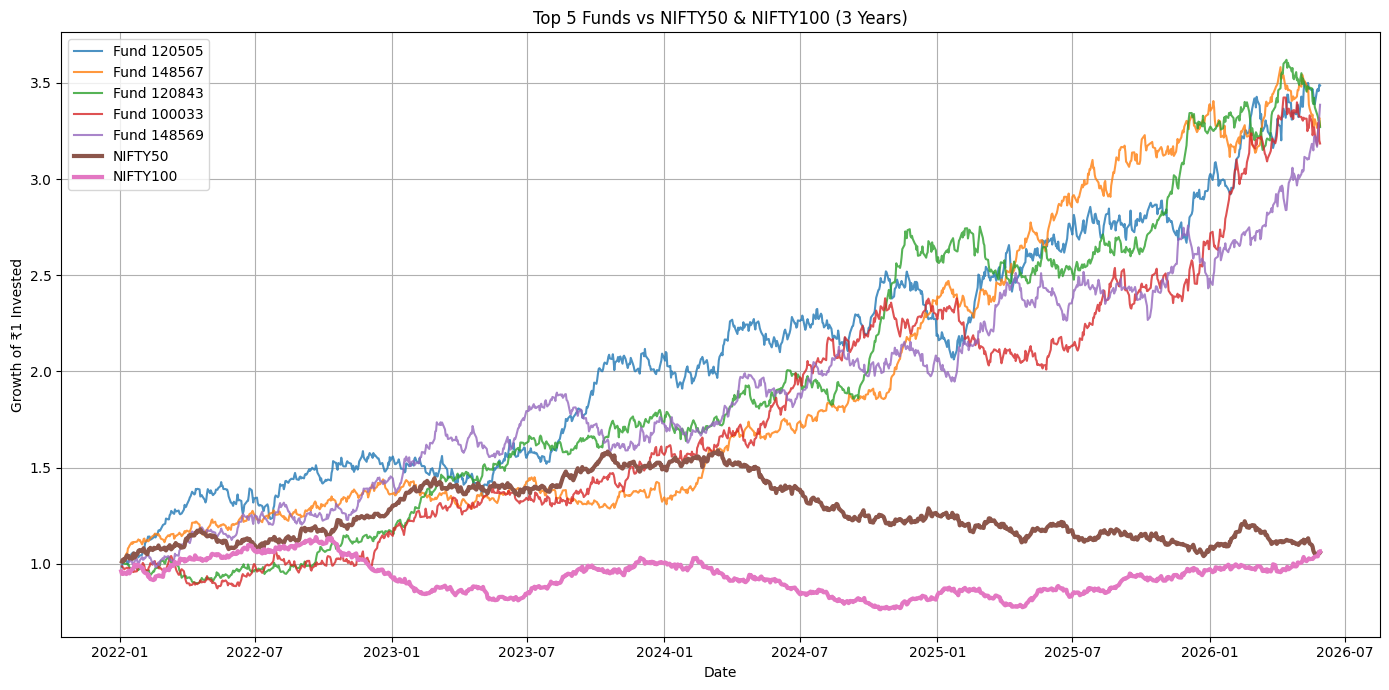


Tracking Errors:
   amfi_code  tracking_error
1     148567        0.189664
2     120843        0.206425
4     148569        0.217365
3     100033        0.228699
0     120505        0.231968


In [55]:
import matplotlib.pyplot as plt

scorecard = scorecard.sort_values('fund_score', ascending=False)

top5_funds = scorecard.head(5)['amfi_code'].tolist()

nifty50 = benchmark[
    benchmark['index_name'] == 'NIFTY50'
].copy()

nifty100 = benchmark[
    benchmark['index_name'] == 'NIFTY100'
].copy()

nifty50['cum_return'] = (
    1 + nifty50['market_return']
).cumprod()

nifty100['cum_return'] = (
    1 + nifty100['market_return']
).cumprod()

nav_top5 = nav[
    nav['amfi_code'].isin(top5_funds)
].copy()

nav_top5 = nav_top5.sort_values(['amfi_code', 'date'])

nav_top5['cum_return'] = (
    1 + nav_top5['daily_return']
).groupby(nav_top5['amfi_code']).cumprod()

plt.figure(figsize=(14, 7))

for fund in top5_funds:

    temp = nav_top5[
        nav_top5['amfi_code'] == fund
    ]

    plt.plot(
        temp['date'],
        temp['cum_return'],
        label=f'Fund {fund}',
        alpha=0.8
    )

plt.plot(
    nifty50['date'],
    nifty50['cum_return'],
    linewidth=3,
    label='NIFTY50'
)

plt.plot(
    nifty100['date'],
    nifty100['cum_return'],
    linewidth=3,
    label='NIFTY100'
)

plt.title('Top 5 Funds vs NIFTY50 & NIFTY100 (3 Years)')
plt.xlabel('Date')
plt.ylabel('Growth of ₹1 Invested')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('benchmark_chart.png')
plt.show()



tracking_errors = []

for fund in top5_funds:

    fund_data = nav[
        nav['amfi_code'] == fund
    ][['date', 'daily_return']]

    merged = fund_data.merge(
        nifty100[['date', 'market_return']],
        on='date',
        how='inner'
    )

    merged = merged.dropna()

    active_return = (
        merged['daily_return']
        - merged['market_return']
    )

    tracking_error = (
        active_return.std()
        * np.sqrt(252)
    )

    tracking_errors.append({
        'amfi_code': fund,
        'tracking_error': tracking_error
    })

tracking_df = pd.DataFrame(tracking_errors)

print("\nTracking Errors:")
print(tracking_df.sort_values('tracking_error'))

tracking_df.to_csv('../data/processed/tracking_error_report.csv',index=False)
